In [10]:
import torch 
import torch.nn as nn
import importlib 

# Develop per-channel feature-based attention moduel

#### Current attentional gain blocks apply one set of parameters to all channel x frequency features at a layer. 

#### Want: Develop channel-specific gain modules 




## Current "simple" attentional gain

In [ ]:
class SimpleAttentionalGain(nn.Module):
    def __init__(self, frequency_dim, cnn_channels):
        super(SimpleAttentionalGain, self).__init__()
        self.time_average = nn.AdaptiveAvgPool2d((frequency_dim, 1)) # outsize is N, C, FreqDim, 1
        self.bias = nn.Parameter(torch.zeros(1)) # init gain scaling to zero
        self.slope = nn.Parameter(torch.ones(1)) # init slope to one
        self.threshold = nn.Parameter(torch.zeros(1)) # init threshold to zero
        self.reset_parameters() 

    def reset_parameters(self):
        nn.init.constant_(self.bias, 0)
        nn.init.constant_(self.slope, 1)
        nn.init.constant_(self.threshold, 0)

    def forward(self, cue, mixture):
        ## Process cue 
        cue = self.time_average(cue)
        # apply threshold shift
        cue = cue - self.threshold
        # apply slope
        cue = cue * self.slope
        # apply sigmoid & bias
        cue = self.bias + (1-self.bias) * torch.sigmoid(cue)
        # Apply to mixture (element mult)
        mixture = torch.mul(mixture, cue)
        return mixture


## Test per-channel implementations

In [ ]:
# Generate dummy inputs 
n_channels = 12

bias = nn.Parameter(torch.zeros(1,n_channels,1,1)) * 0.24# make 4D for broadcastable ops 
slope = nn.Parameter(torch.ones(1,n_channels,1,1)) * 100 # make 4D for broadcastable ops 
threshold = nn.Parameter(torch.zeros(1,n_channels,1,1))  * 0.0045# make 4D for broadcastable ops 


x_in = torch.rand(2,n_channels,4,24)  # Eg N,C,H,W == N,C,F,T here 

# time average
cue = x_in.mean(-1).unsqueeze(-1) # same as F.adaptive_average_pool_2d
cue = (cue - cue.mean()) / cue.max()
print(cue.shape)

output = bias + (1 - bias) * torch.sigmoid(slope * (cue - threshold))
print(output.shape)

attn = torch.mul(x_in, output)
print(attn.shape)

torch.Size([2, 12, 4, 1])
torch.Size([2, 12, 4, 1])
torch.Size([2, 12, 4, 24])


(array([[267.,  43.,  47.,  28.,  31.,  35.,  32.,  27.,  35.,  31.],
        [268.,  25.,  34.,  42.,  38.,  36.,  37.,  35.,  31.,  30.]]),
 array([1.3293783e-15, 9.9917874e-02, 1.9983575e-01, 2.9975361e-01,
        3.9967149e-01, 4.9958935e-01, 5.9950721e-01, 6.9942510e-01,
        7.9934299e-01, 8.9926082e-01, 9.9917871e-01], dtype=float32),
 <a list of 2 BarContainer objects>)

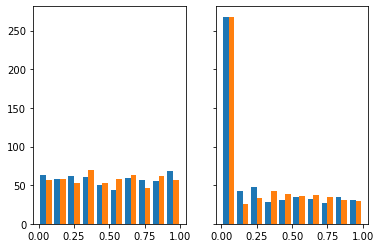

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns 

n_hist_bins = 100

fig, axs = plt.subplots(1,2, sharey=True)

# sns.histplot(cue.detach().numpy(), stat='percent',  log_scale=(False, True),
#              bins=n_hist_bins, #binrange=(layer_outputs.min(), layer_outputs.max()),
#              ax=axs[0], color='plum', edgecolor='0.1')


# sns.histplot(output.detach().numpy().flatten(), stat='percent',  log_scale=(False, True),
#              bins=n_hist_bins, #binrange=(layer_outputs.min(), layer_outputs.max()),
#              ax=axs[1], color='teal', edgecolor='0.1')

axs[0].hist(x_in.detach().numpy()[0].reshape(2,-1).T)
axs[1].hist(attn.detach().numpy()[0].reshape(2,-1).T)


In [18]:
import torch 
import numpy as np 
import h5py
import os
from pathlib import Path
import importlib

import src.attn_tracking_lightning as lightning 
importlib.reload(lightning)
import yaml
from pytorch_lightning import Trainer


os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

config_path = "config/attentional_cue/attn_cue_speech_and_noise_coch_only.yaml"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)
config['data']['loader']['batch_size'] = 2
config['data']['loader']['num_workers'] = 0

module = lightning.AttentionalTrackingModule(config)

ln_first
Using attention at cochleagram only
center_crop=False
binaural=False
using FIR cochleagram


In [19]:
trainer = Trainer(
    precision=16,
    # default_root_dir='test_log_dump/',
    # val_check_interval=1000,
#     limit_train_batches=0.,
    limit_val_batches=0.0,
    num_nodes=1,
    gpus=1,
    # detect_anomaly=True,
    accelerator="gpu",
)

Using 16bit native Automatic Mixed Precision (AMP)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pytorch_lightning/loops/utilities.py:91: PossibleUserWarning: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
  rank_zero_warn(
GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [20]:
trainer.fit(module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                  | Type                   | Params
-----------------------------------------------------------------
0 | bg_combine_transforms | AudioCompose           | 0     
1 | audio_transforms      | AudioCompose           | 0     
2 | model                 | AttnSequentialAttacker | 66.9 M
3 | loss_fn               | CrossEntropyLoss       | 0     
4 | train_acc             | Accuracy               | 0     
5 | valid_acc             | Accuracy               | 0     
6 | test_acc              | Accuracy               | 0     
7 | test_confusion        | Accuracy               | 0     
-----------------------------------------------------------------
66.9 M    Trainable params
0         Non-trainable params
66.9 M    Total params
133.846   Total estimated model params size (MB)


<class 'corpus.jsinV3_attn_cue_multi_source.jsinV3_attn_cue_multi_source'>


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:240: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 48 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Epoch 0:   0%|          | 50/2905300 [00:18<304:19:37,  2.65it/s, loss=6.67, v_num=3.08e+7]

2023-05-23 17:17:01.774959: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 0:   0%|          | 507/2905300 [02:59<286:23:14,  2.82it/s, loss=6.67, v_num=3.08e+7]

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pytorch_lightning/trainer/trainer.py:726: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")
